# Access MODIS data using openEO

The Copernicus Data Space Ecosystem (CDSE) also offers MODIS (Moderate Resolution Imaging Spectroradiometer), a 36-band multispectral scanner that measures visible-to-thermal-infrared radiances for atmosphere, land, and ocean monitoring. Registered CDSE users can access it directly through the OData API, but if you also want to search, subset, and process the data as part of a larger workflow, accessing them from the STAC catalogue using openEO is often the more convenient solution.

openEO is generally used to run processing directly in the cloud; simple examples include computing vegetation indices, aggregating time series, or masking clouds, without first downloading the underlying data on your own machine. However, the goal of this notebook is to show how to discover and fetch a MODIS collection and access it using openEO.

Before connecting and fetching data with openEO, let's first explore what MODIS products are available as STAC collections in the CDSE catalogue. For more information about this data, see the documentation: https://documentation.dataspace.copernicus.eu/Data.html

In [1]:
from pystac_client import Client

Let's connect to the CDSE STAC catalogue.

In [2]:
stac_url = "https://stac.dataspace.copernicus.eu/v1/"
client = Client.open(stac_url)

collections = list(client.get_collections())
print(f"Total collections available in CDSE STAC catalogue: {len(collections)}")

Total collections available in CDSE STAC catalogue: 422


At the time of preparing this notebook, the CDSE STAC catalogue held several hundred collections across many missions. Since we're only interested in MODIS here, so let us simply filter down to collections whose ID starts with "modis".

In [3]:
# get the collection whose id starts with "modis"
modis_collections = [c for c in collections if c.id.startswith("modis")]
print(f"Found {len(modis_collections)} collections that start with 'modis'")

Found 40 collections that start with 'modis'


Each MODIS collection differs by product type, spatial resolution, and temporal revisit(e.g. daily vs 8-day vs 16-day composites). Let's print a few of them, along with their descriptions, to get a sense of what's on offer.

In [4]:
# print top 5 collections
for c in modis_collections[:10]:
    print(f"Collection ID: {c.id}, Title: {c.title}, Description: {c.description}")

Collection ID: modis-aqua-myd09a1, Title: MODIS Aqua Surface Reflectance 8-Day L3 Global 500m, Description: The MODIS Aqua MYD09A1 Version 6.1 product provides atmospherically corrected Surface Reflectance for MODIS Bands 1-7 at 500 m spatial resolution. The data are corrected for atmospheric effects including gases, aerosols, and Rayleigh scattering. The product is generated as an 8-day composite, where for each pixel the best observation is selected from all acquisitions within the compositing period based on criteria such as cloud conditions and solar zenith angle. When multiple observations meet these criteria, the pixel with the lowest value in Band 3 (blue) is selected. The product also includes a quality assurance layer and four observation bands to support data reliability and interpretation.
Collection ID: modis-aqua-myd09q1, Title: MODIS Aqua Surface Reflectance 8-Day L3 Global 250m, Description: The MODIS Aqua MYD09Q1 Version 6.1 product provides atmospherically corrected Su

From the list of IDs and descriptions above, let us say we are interested only in the 8-day composite Land Surface Temperature & Emissivity product, for the region of Antwerp, Belgium, over the summer period of 2024.

In [7]:
collection_id = "modis-aqua-myd11a2"
stac_url = f"https://stac.dataspace.copernicus.eu/v1/collections/{collection_id}"

Now let's access this same collection using openEO. Rather than pulling the full global tiles and cropping them ourselves, openEO lets us pass the STAC collection URL along with a spatial and temporal extent, and the subsetting happens on the server side, so we fetch only the data we need.

In [8]:
import openeo

connection = openeo.connect("openeo-staging.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


In [9]:
stac_cube = connection.load_stac(
    stac_url,
    temporal_extent=["2024-01-01", "2024-01-31"], 
    spatial_extent={"west": 4.137726, "south": 50.986963, "east": 4.994659, "north": 51.334044}
)

Now, we submit the openEO batch job, openEO processes it in the CDSE cloud, and we poll until it is done.

In [10]:
job = stac_cube.create_job(title = "LST Daily MODIS example")
job.start_and_wait()

0:00:00 Job 'j-260716120732419e86d9c4719b9ed42e': send 'start'
0:00:04 Job 'j-260716120732419e86d9c4719b9ed42e': queued (progress 0%)
0:00:09 Job 'j-260716120732419e86d9c4719b9ed42e': queued (progress 0%)
0:00:15 Job 'j-260716120732419e86d9c4719b9ed42e': queued (progress 0%)
0:00:24 Job 'j-260716120732419e86d9c4719b9ed42e': queued (progress 0%)
0:00:33 Job 'j-260716120732419e86d9c4719b9ed42e': queued (progress 0%)
0:00:46 Job 'j-260716120732419e86d9c4719b9ed42e': queued (progress 0%)
0:01:01 Job 'j-260716120732419e86d9c4719b9ed42e': queued (progress 0%)
0:01:20 Job 'j-260716120732419e86d9c4719b9ed42e': running (progress 11.5%)
0:01:44 Job 'j-260716120732419e86d9c4719b9ed42e': running (progress 14.5%)
0:02:14 Job 'j-260716120732419e86d9c4719b9ed42e': running (progress 18.0%)
0:02:52 Job 'j-260716120732419e86d9c4719b9ed42e': running (progress 22.0%)
0:03:39 Job 'j-260716120732419e86d9c4719b9ed42e': running (progress 26.5%)
0:04:37 Job 'j-260716120732419e86d9c4719b9ed42e': running (progre

<BatchJob job_id='j-260716120732419e86d9c4719b9ed42e'>

In [12]:
results = job.get_results()
results.download_files("modis_access/")  # Specify your download directory

[WindowsPath('modis_access/openEO_2024-01-01Z.tif'),
 WindowsPath('modis_access/openEO_2024-01-09Z.tif'),
 WindowsPath('modis_access/openEO_2024-01-17Z.tif'),
 WindowsPath('modis_access/openEO_2024-01-25Z.tif'),
 WindowsPath('modis_access/job-results.json')]

With the data downloaded locally, let us visualise it using standard python packages. Firstly, let us have a quick grid of all the days we fetched to get an overview, and then a single day rendered on an interactive map for a closer look.

In [9]:
import os
import glob
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import Normalize
import imageio.v2 as imageio

Found 4 files


C:\Users\SHARMAP\AppData\Local\Temp\ipykernel_25336\3110570976.py:12: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  data = src.read(1).astype(float)
C:\Users\SHARMAP\AppData\Local\Temp\ipykernel_25336\3110570976.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


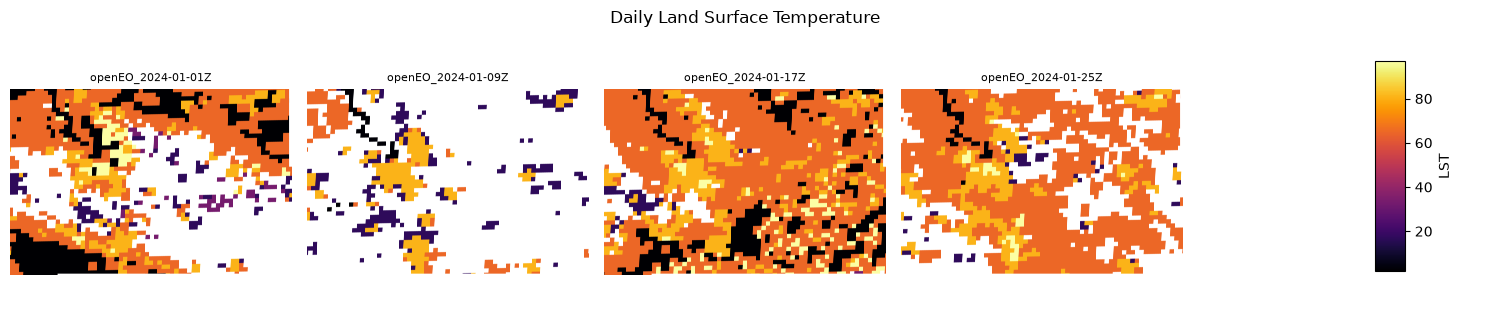

In [10]:
folder = "modis_access/"         
pattern = "*.tif"                         

files = sorted(glob.glob(os.path.join(folder, pattern)))
print(f"Found {len(files)} files")

arrays = []
dates = []

for f in files:
    with rasterio.open(f) as src:
        data = src.read(1).astype(float)
        nodata = src.nodata
        if nodata is not None:
            data[data == nodata] = np.nan
        arrays.append(data)
        dates.append(os.path.splitext(os.path.basename(f))[0])

arrays = np.array(arrays)  # shape: (n_days, rows, cols)

# having a consistent color scale across all days
vmin = np.nanpercentile(arrays, 2)
vmax = np.nanpercentile(arrays, 98)

# subplots for each day
n = len(arrays)
ncols = 5
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
axes = np.array(axes).reshape(-1)

for i, ax in enumerate(axes):
    if i < n:
        im = ax.imshow(arrays[i], cmap="inferno", vmin=vmin, vmax=vmax)
        ax.set_title(dates[i], fontsize=8)
    ax.axis("off")

fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label="LST")
plt.suptitle("Daily Land Surface Temperature", y=1.02)
plt.tight_layout()
plt.savefig("lst_subplots.png", dpi=150, bbox_inches="tight")
plt.show()

Let's take a closer look at one specific date from the series and plot it as an overlay on an interactive map.

In [7]:
import rasterio
import numpy as np
import matplotlib
import folium

tif_file = "modis_access/openEO_2024-01-17Z.tif"

with rasterio.open(tif_file) as src:
    data = src.read(1).astype(float)

    if src.nodata is not None:
        data[data == src.nodata] = np.nan

    bounds = src.bounds
    crs = src.crs

print(crs)
print(bounds)

EPSG:32631
BoundingBox(left=579250.0, bottom=5648990.0, right=640000.0, top=5688870.0)


C:\Users\SHARMAP\AppData\Local\Temp\ipykernel_25336\731936397.py:9: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  data = src.read(1).astype(float)


In [3]:
cmap = matplotlib.colormaps.get_cmap("inferno")

vmin = np.nanpercentile(data, 2)
vmax = np.nanpercentile(data, 98)

norm = np.clip((data - vmin) / (vmax - vmin), 0, 1)

rgba = cmap(norm)
rgba[..., 3] = np.where(np.isnan(data), 0, 0.7)  # transparency


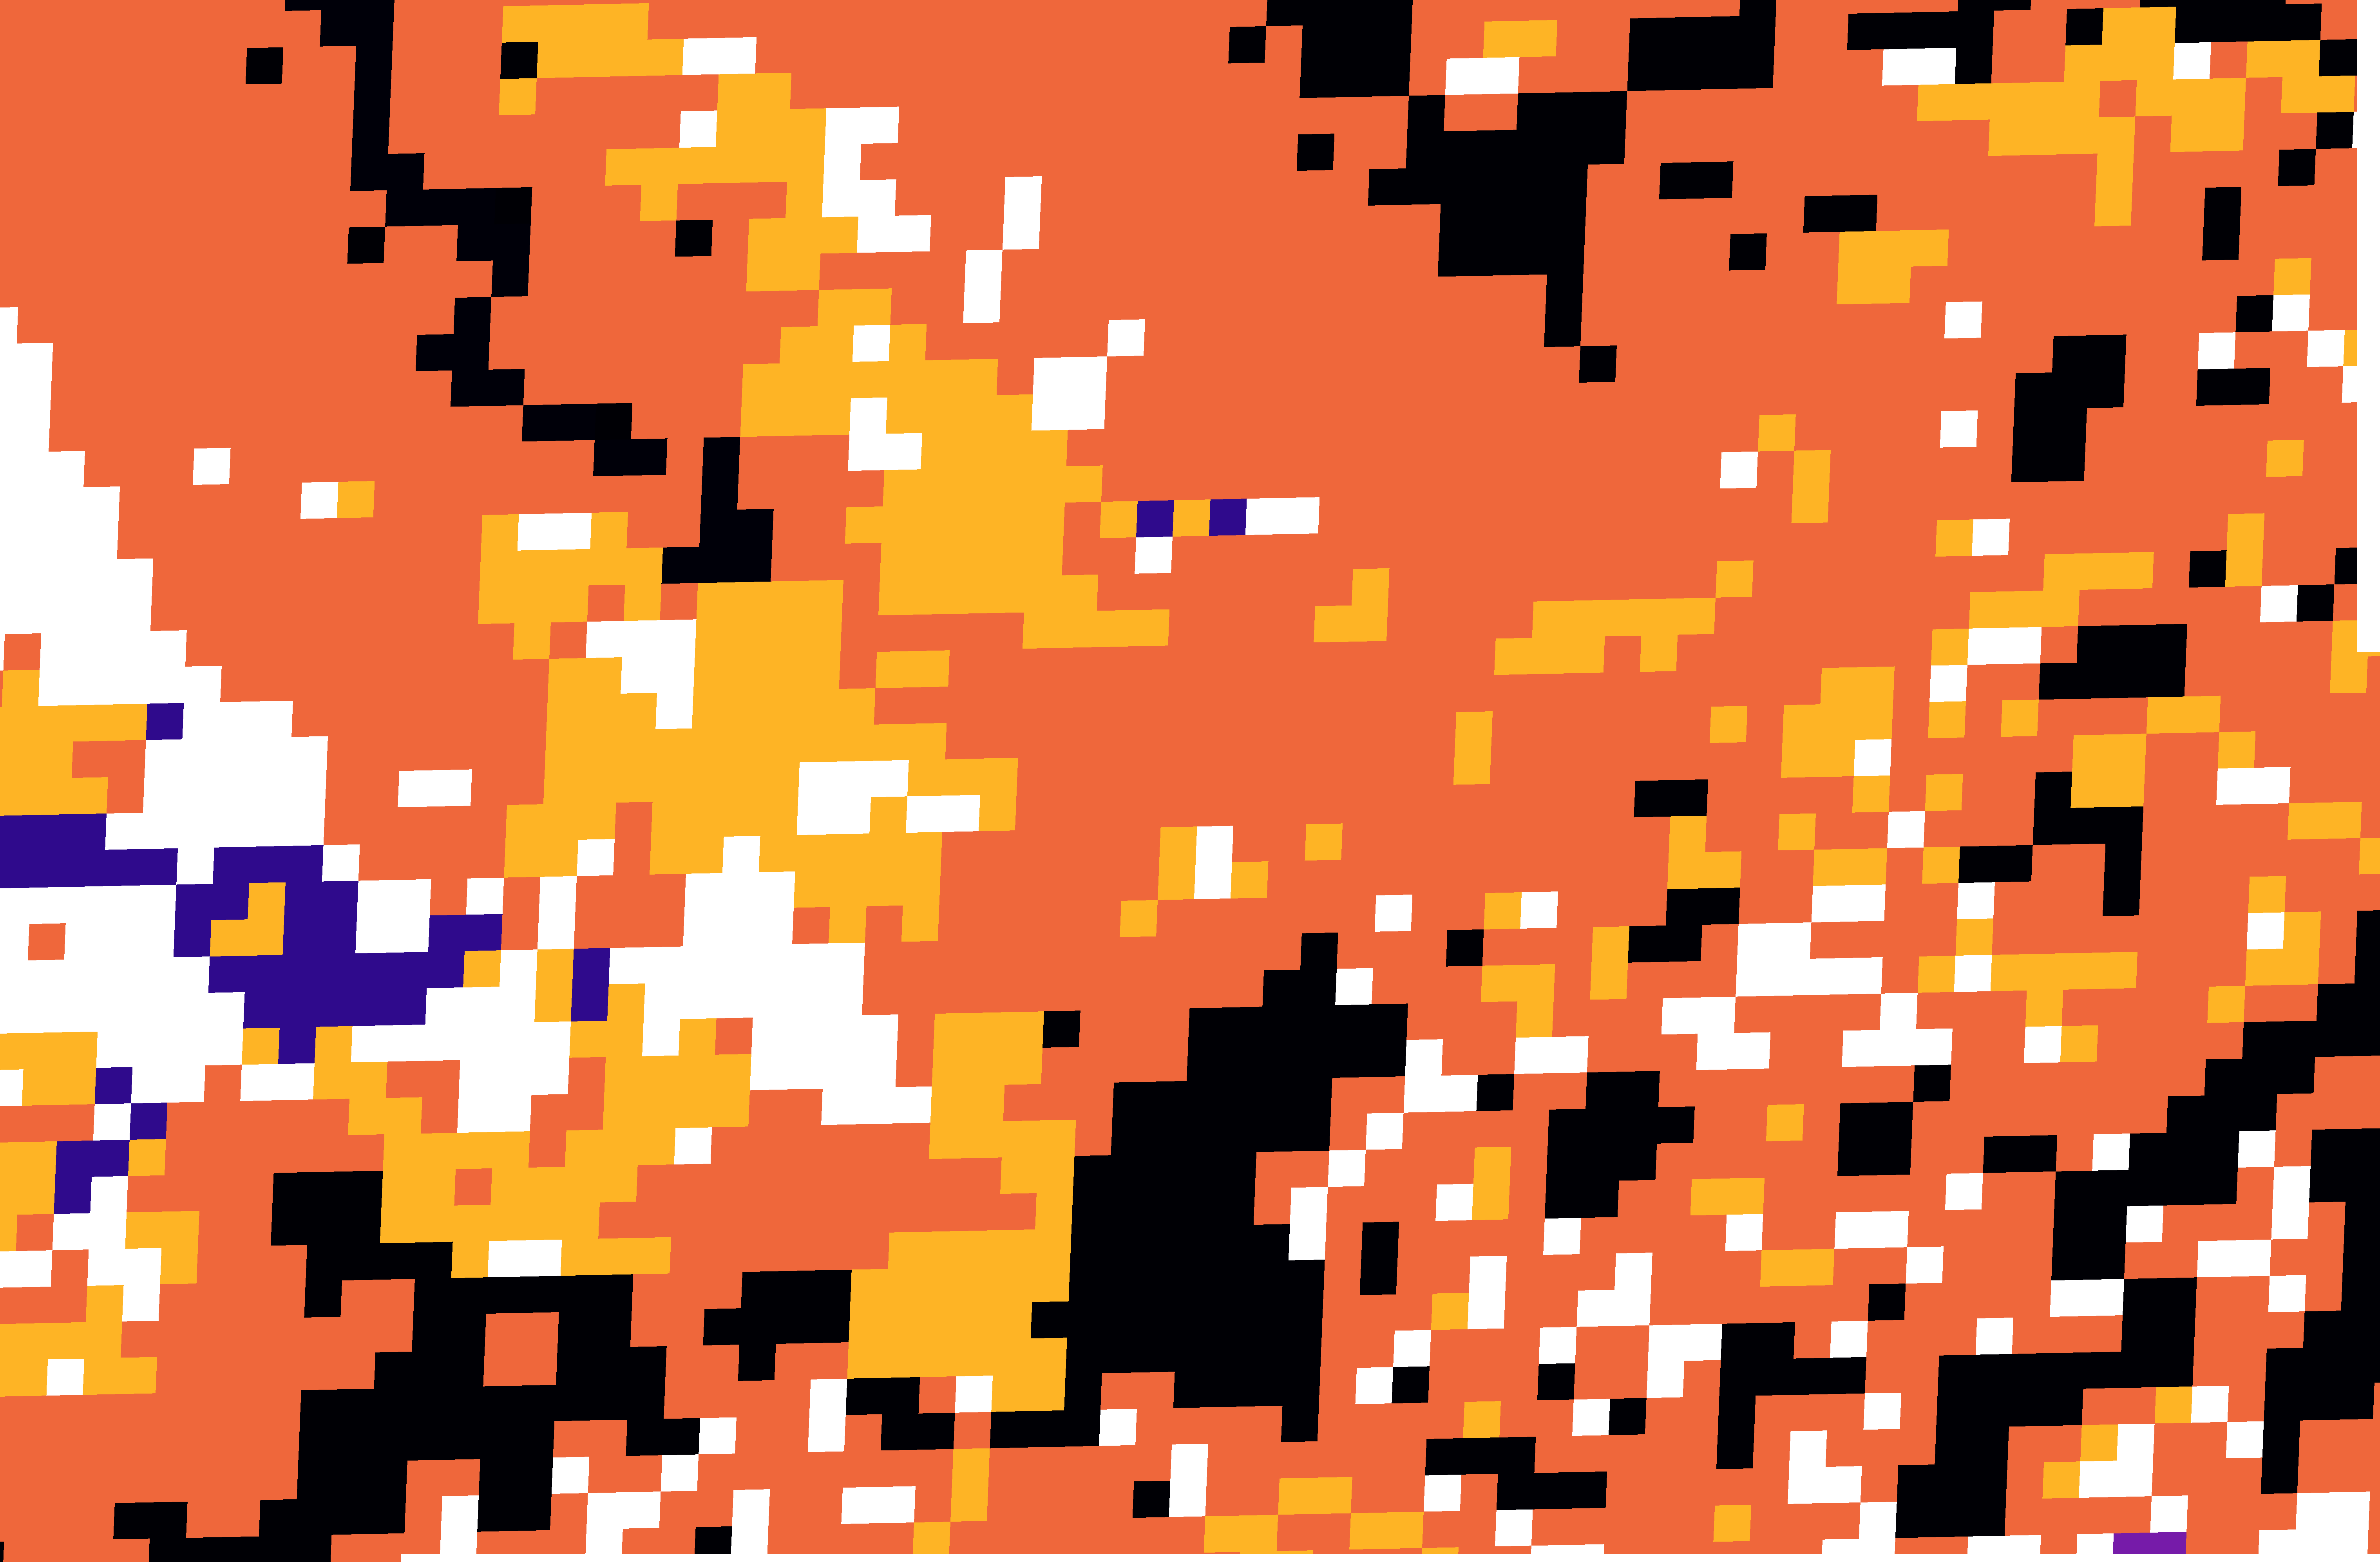

In [6]:
m = folium.Map(
    location=[
        (bounds.bottom + bounds.top) / 2,
        (bounds.left + bounds.right) / 2
    ],
    zoom_start=7
)

folium.raster_layers.ImageOverlay(
    image=rgba,
    bounds=[
        [bounds.bottom, bounds.left],
        [bounds.top, bounds.right]
    ],
    opacity=0.7
).add_to(m)

folium.LayerControl().add_to(m)

display(m)

In this notebook, we explored the MODIS collections offered in the CDSE STAC catalogue, selected one of the products of interest, fetched a subset of it using openEO, and visualised the result both as a time-series grid and as an interactive map layer. The same `load_stac` process can be used for any of the other MODIS collections, or in fact any other STAC collection offered in CDSE STAC.